<a href="https://colab.research.google.com/github/toni2174301/CFF-/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import + Loading

In [2]:

!pip install odfpy -q
!git clone https://github.com/toni2174301/CFF-.git
%cd CFF-


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 29.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Cloning into 'CFF-'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 33 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 5.11 MiB | 7.08 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/CFF-


In [3]:
!pip install contextily geopandas shap -q

# Core
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Geo
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data splitting
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Supervised models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Unsupervised models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# Interpretability
import shap

# Misc
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:

import os

GITHUB_REPO_URL = "https://github.com/toni2174301/CFF-.git"
CSV_PATH        = "real_estate_data.csv"


REPO_NAME = GITHUB_REPO_URL.split("/")[-1].replace(".git", "")

if not os.path.exists(f"/content/{REPO_NAME}"):
    os.system(f"git clone {GITHUB_REPO_URL}")
    print(f"Repo cloned: {REPO_NAME}")
else:
    print(f"Repo already cloned, pulling latest changes...")
    os.system(f"cd /content/{REPO_NAME} && git pull")

os.chdir(f"/content/{REPO_NAME}")
print(f"Working directory: {os.getcwd()}")

df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded -- {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Repo already cloned, pulling latest changes...
Working directory: /content/CFF-
Dataset loaded -- 20,640 rows x 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.2300,37.8800,41,880,129.0000,322,126,8.3252,NEAR BAY,452600
1,-122.2200,37.8600,21,7099,1106.0000,2401,1138,8.3014,NEAR BAY,358500
2,-122.2400,37.8500,52,1467,190.0000,496,177,7.2574,NEAR BAY,352100
3,-122.2500,37.8500,52,1274,235.0000,558,219,5.6431,NEAR BAY,341300
4,-122.2500,37.8500,52,1627,280.0000,565,259,3.8462,NEAR BAY,342200


##Cleaning

In [5]:
# ============================================================
# CELL 4 - DUPLICATE CHECK
# ============================================================

n_duplicates = df.duplicated().sum()

if n_duplicates == 0:
    print("No duplicate rows found.")
else:
    print(f"Found {n_duplicates} duplicate rows ({n_duplicates / len(df) * 100:.2f}% of data).")
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)))
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

No duplicate rows found.


In [6]:
# ============================================================
# CELL 5 - DATA CLEANING
# ============================================================

df_clean = df.copy()

# --- 1. Remove capped target values (artificial ceiling at 500,001) ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['median_house_value'] < 500000]
print(f"Removed capped target rows: {n_before - len(df_clean)}")

# --- 2. Remove ISLAND category (only 5 rows, too rare) ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['ocean_proximity'] != 'ISLAND']
print(f"Removed ISLAND rows: {n_before - len(df_clean)}")

# --- 3. Impute missing total_bedrooms with median ---
median_bedrooms = df_clean['total_bedrooms'].median()
df_clean['total_bedrooms'] = df_clean['total_bedrooms'].fillna(median_bedrooms)
print(f"Imputed total_bedrooms NAs with median: {median_bedrooms}")

# --- 4. Feature engineering: per-household ratios ---
df_clean['rooms_per_household']      = df_clean['total_rooms']   / df_clean['households']
df_clean['bedrooms_per_room']        = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population']    / df_clean['households']

# --- 5. Cap outliers on block-level totals at 99th percentile ---
cols_to_cap = ['total_rooms', 'total_bedrooms', 'population', 'households']
for col in cols_to_cap:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"Capped {col} at 99th pct: {cap:.0f}")

# --- 6. Reset index ---
df_clean = df_clean.reset_index(drop=True)

# --- 7. Overwrite df for downstream use ---
df = df_clean

print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining NAs: {df.isnull().sum().sum()}")
df.head()

Removed capped target rows: 992
Removed ISLAND rows: 5
Imputed total_bedrooms NAs with median: 436.0
Capped total_rooms at 99th pct: 11211
Capped total_bedrooms at 99th pct: 2241
Capped population at 99th pct: 5866
Capped households at 99th pct: 1994

Final shape: 19,643 rows x 13 columns
Remaining NAs: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.2300,37.8800,41,880.0000,129.0000,322.0000,126.0000,8.3252,NEAR BAY,452600,6.9841,0.1466,2.5556
1,-122.2200,37.8600,21,7099.0000,1106.0000,2401.0000,1138.0000,8.3014,NEAR BAY,358500,6.2381,0.1558,2.1098
2,-122.2400,37.8500,52,1467.0000,190.0000,496.0000,177.0000,7.2574,NEAR BAY,352100,8.2881,0.1295,2.8023
3,-122.2500,37.8500,52,1274.0000,235.0000,558.0000,219.0000,5.6431,NEAR BAY,341300,5.8174,0.1845,2.5479
4,-122.2500,37.8500,52,1627.0000,280.0000,565.0000,259.0000,3.8462,NEAR BAY,342200,6.2819,0.1721,2.1815


##EDA

In [7]:

# SUMMARY STATISTICS


print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

print("\n=== OCEAN PROXIMITY DISTRIBUTION ===")
print(df['ocean_proximity'].value_counts())

=== SHAPE ===
(19643, 13)

=== DATA TYPES ===
longitude                   float64
latitude                    float64
housing_median_age            int64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
ocean_proximity              object
median_house_value            int64
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

=== DESCRIPTIVE STATISTICS ===
       longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
count 19643.0000 19643.0000          19643.0000   19643.0000      19643.0000   
mean   -119.5627    35.6525             28.3695    2571.2126        530.9477   
std       2.0059     2.1500             12.5022    1849.4881        372.2958   
min    -124.3500    32.5400              1.0000       2.0000          2.0000   
25%    -121.7600    33.9300             

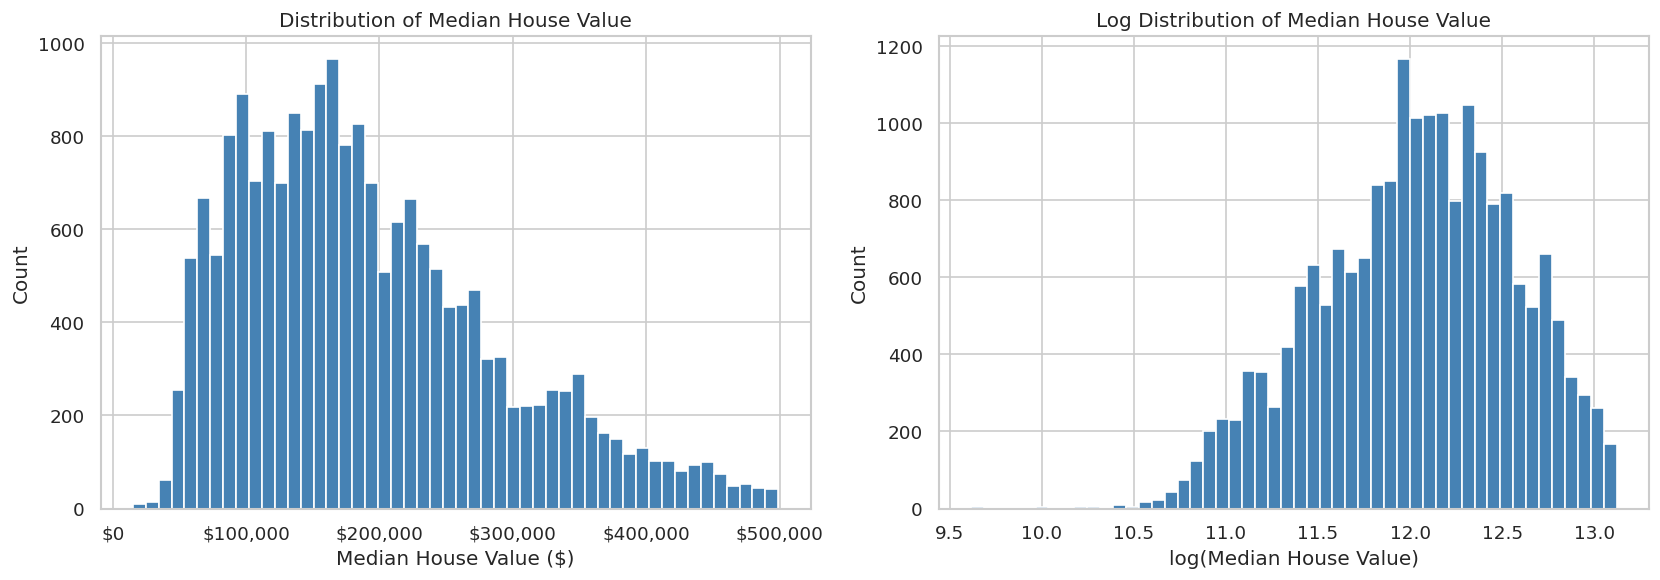

In [8]:
# ============================================================
# CELL 7 - EDA: TARGET DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log Distribution of Median House Value')
axes[1].set_xlabel('log(Median House Value)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

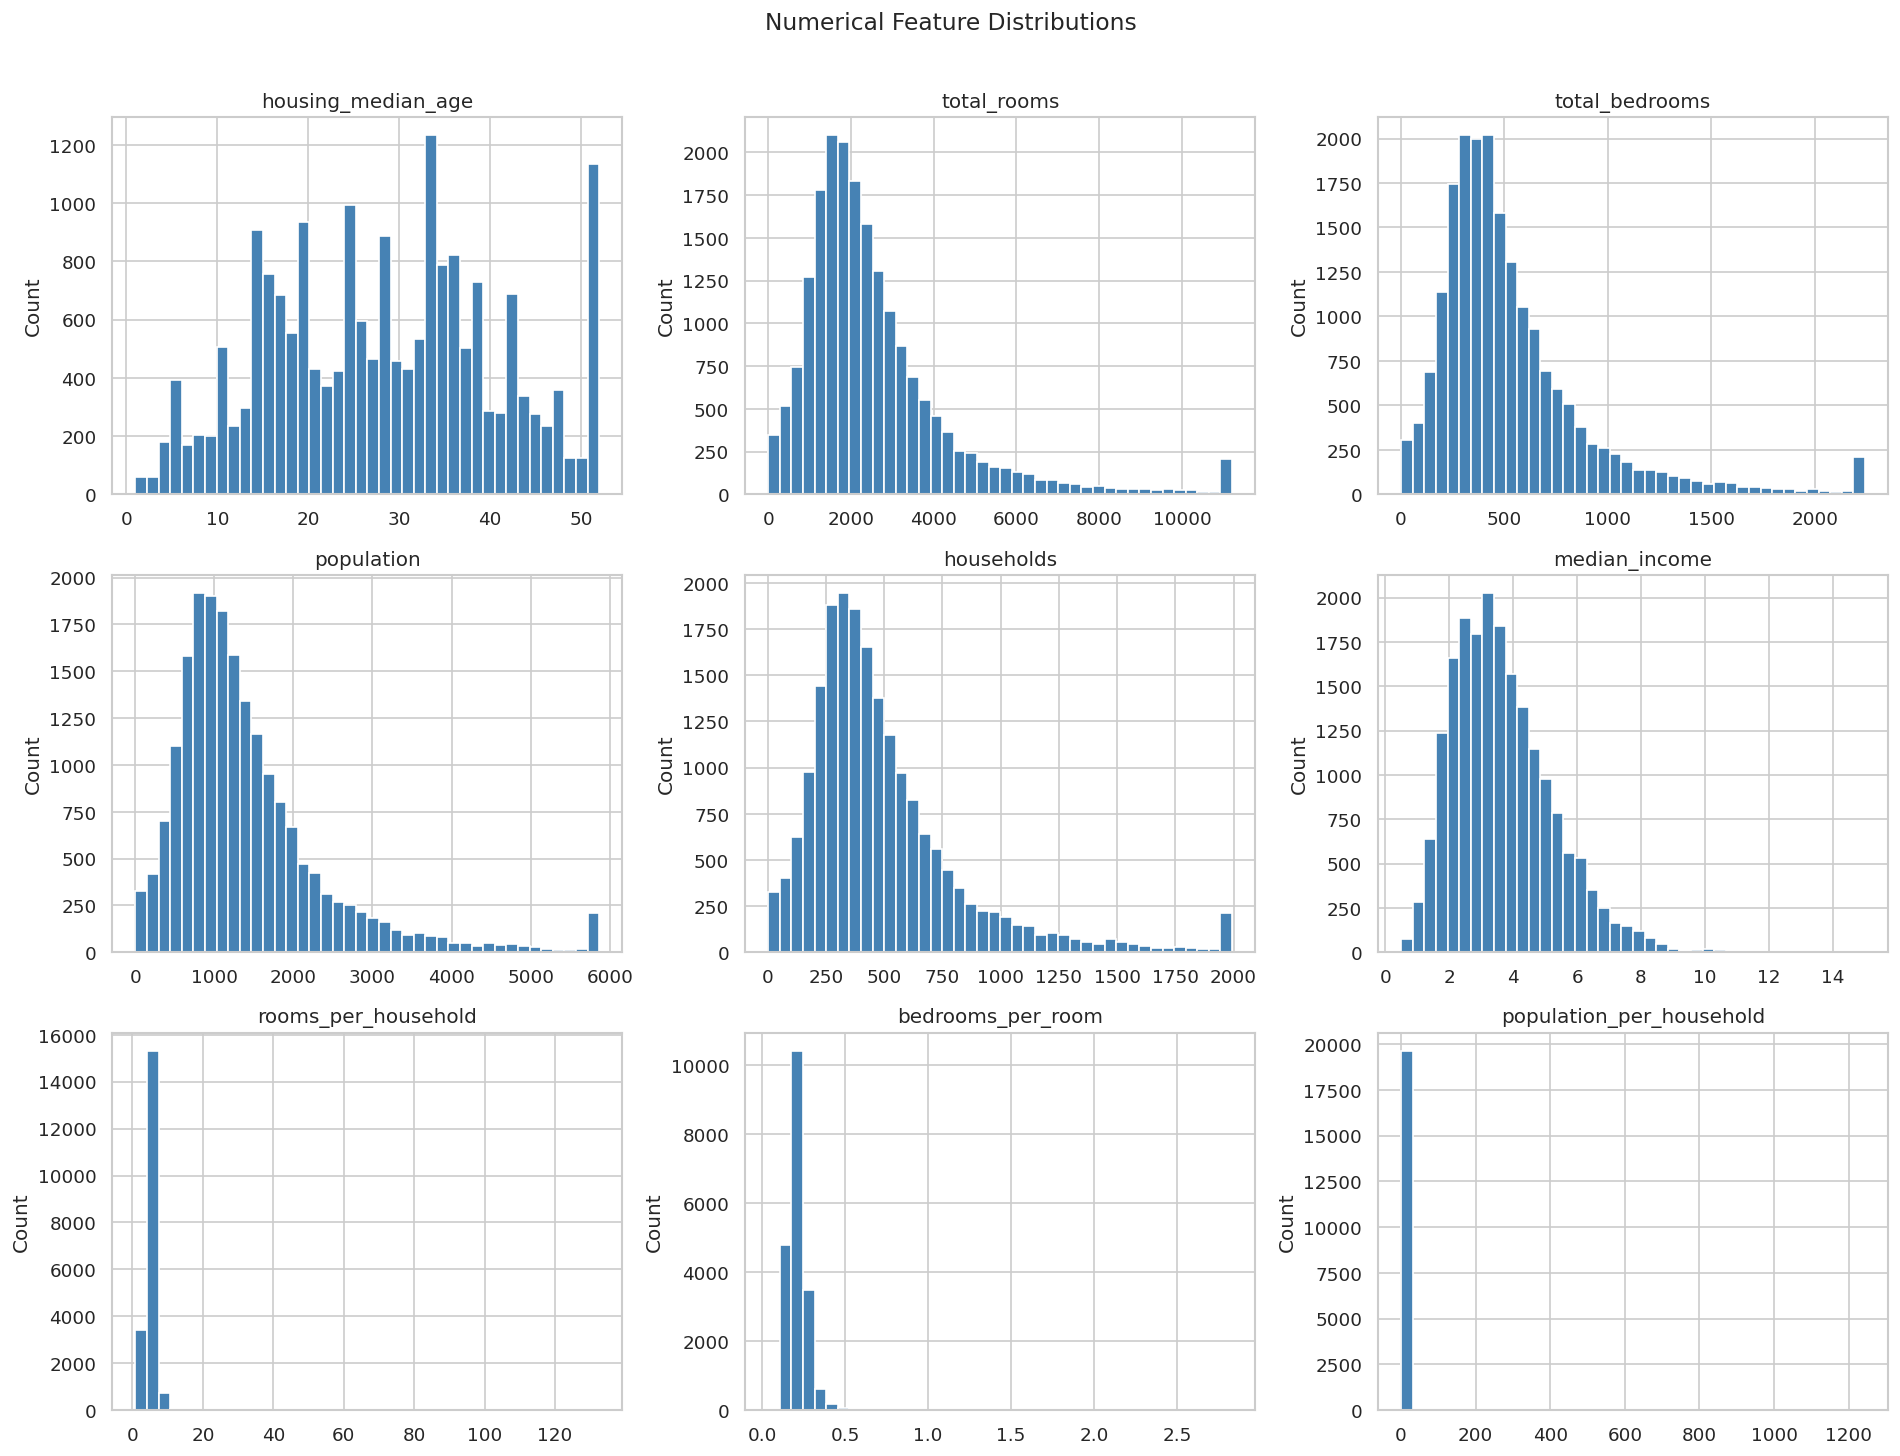

In [9]:
# ============================================================
# CELL 8 - EDA: FEATURE DISTRIBUTIONS
# ============================================================

num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

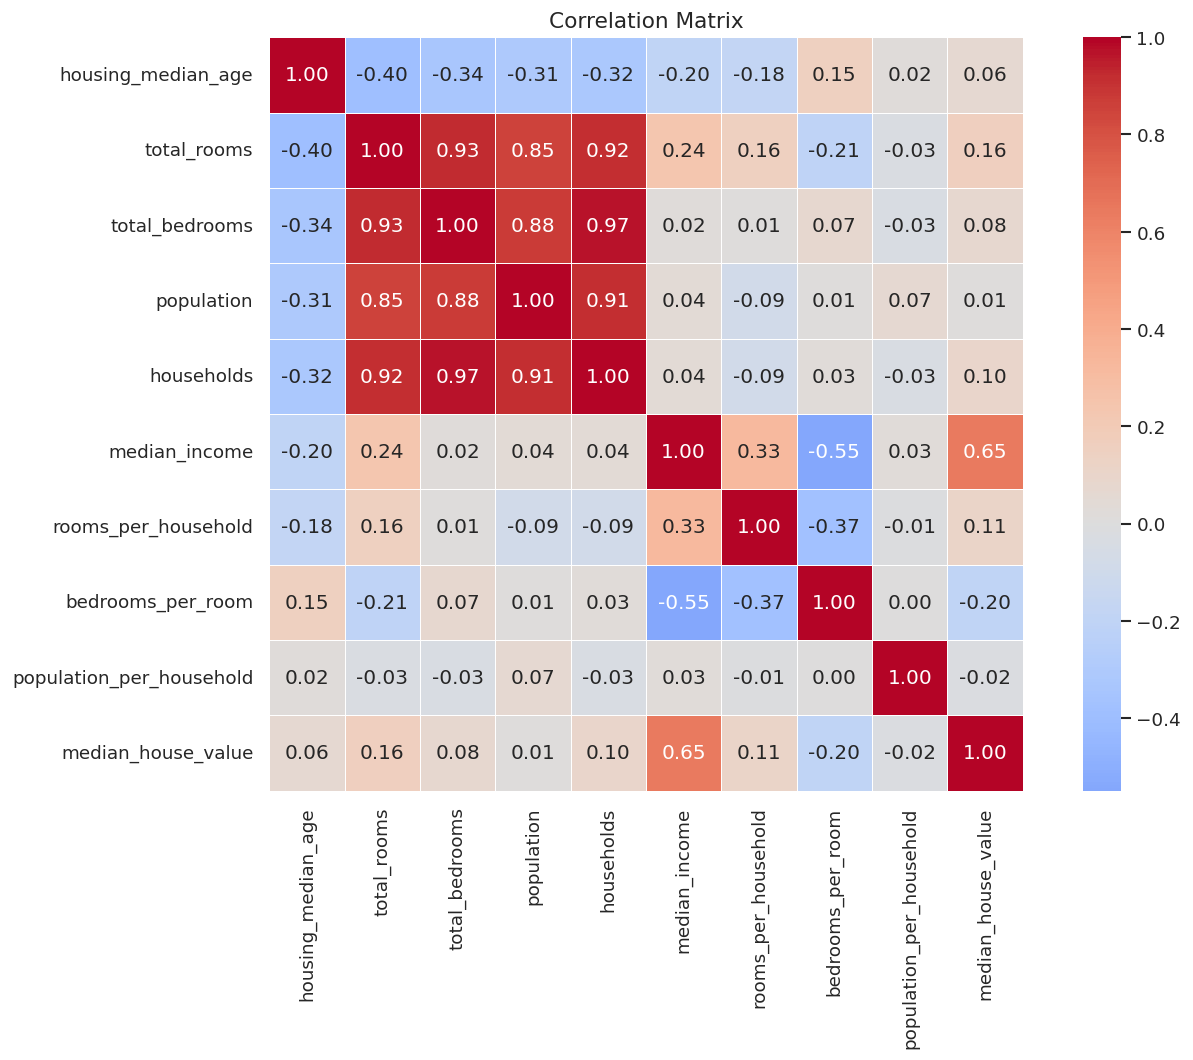

In [10]:
# ============================================================
# CELL 9 - EDA: CORRELATION HEATMAP
# ============================================================

num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

corr_cols = num_cols + ['median_house_value']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

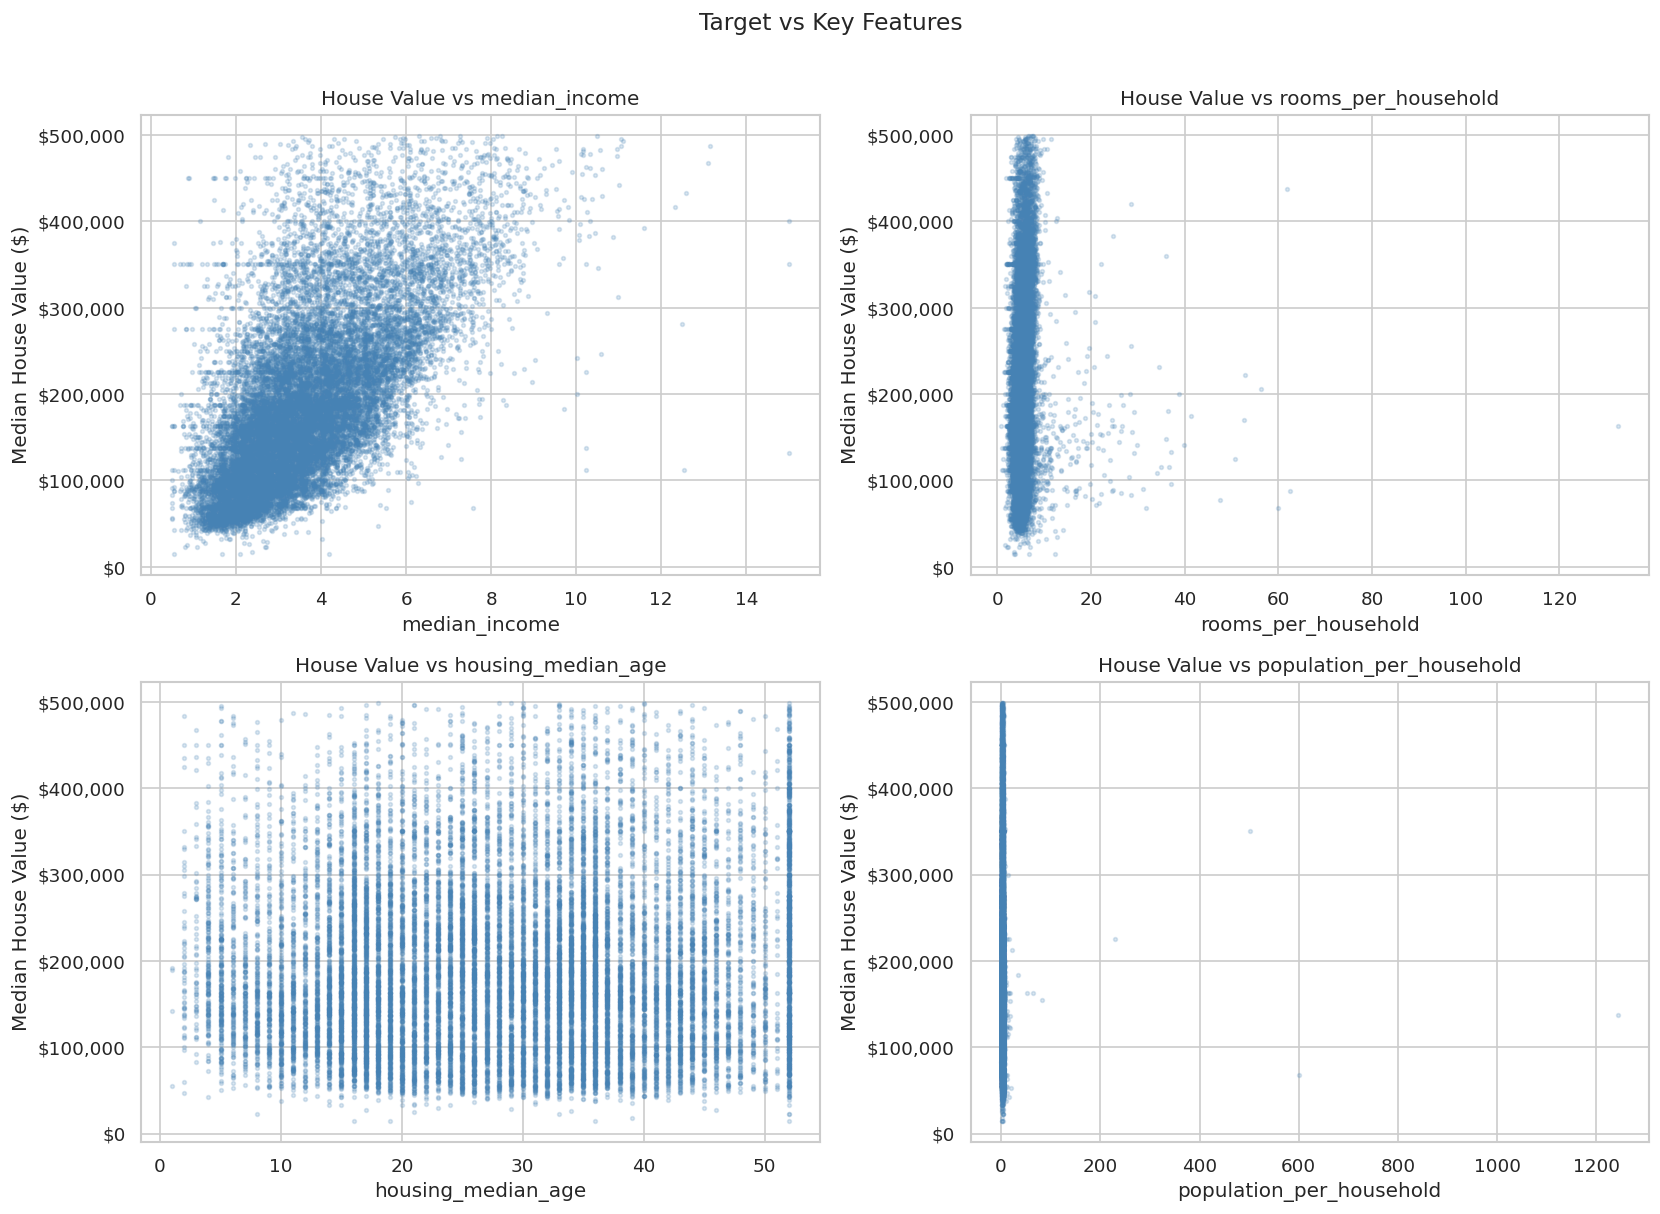

In [11]:
# ============================================================
# CELL 10 - EDA: TARGET VS KEY FEATURES
# ============================================================

key_features = ['median_income', 'rooms_per_household',
                'housing_median_age', 'population_per_household']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].scatter(df[col], df['median_house_value'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median House Value ($)')
    axes[i].set_title(f'House Value vs {col}')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Target vs Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('scatter_target_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

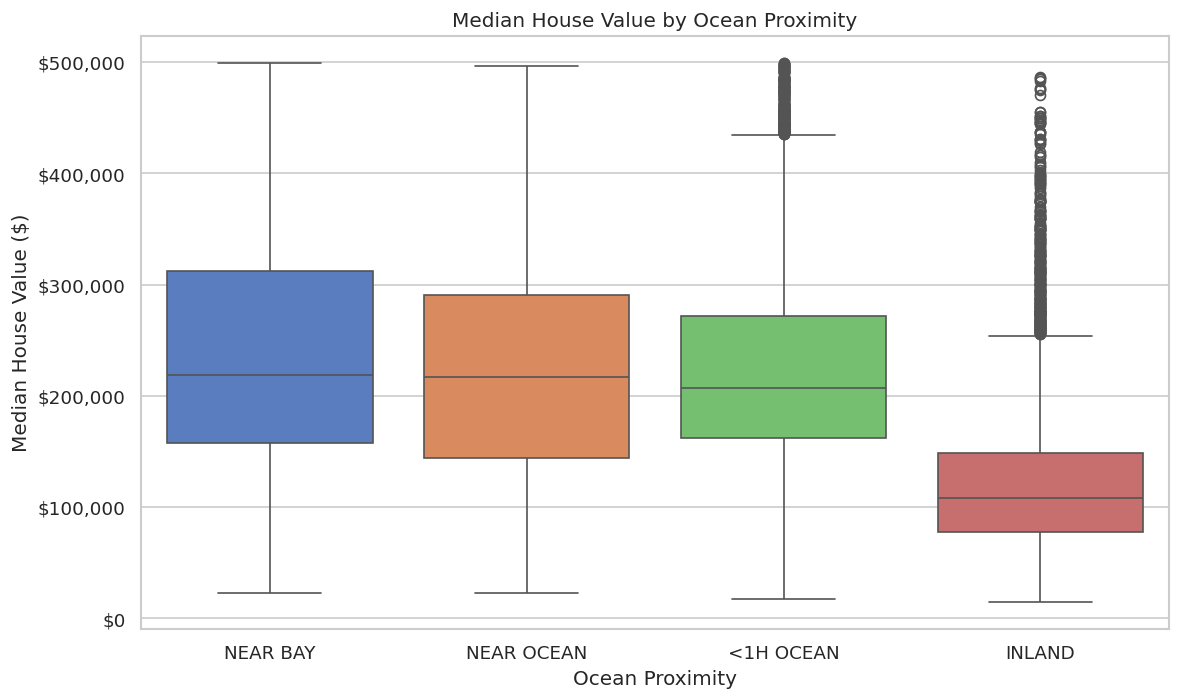

In [12]:
# ============================================================
# CELL 11 - EDA: BOXPLOT BY OCEAN PROXIMITY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    order=order,
    palette='muted',
    ax=ax
)
ax.set_title('Median House Value by Ocean Proximity')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('boxplot_ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()

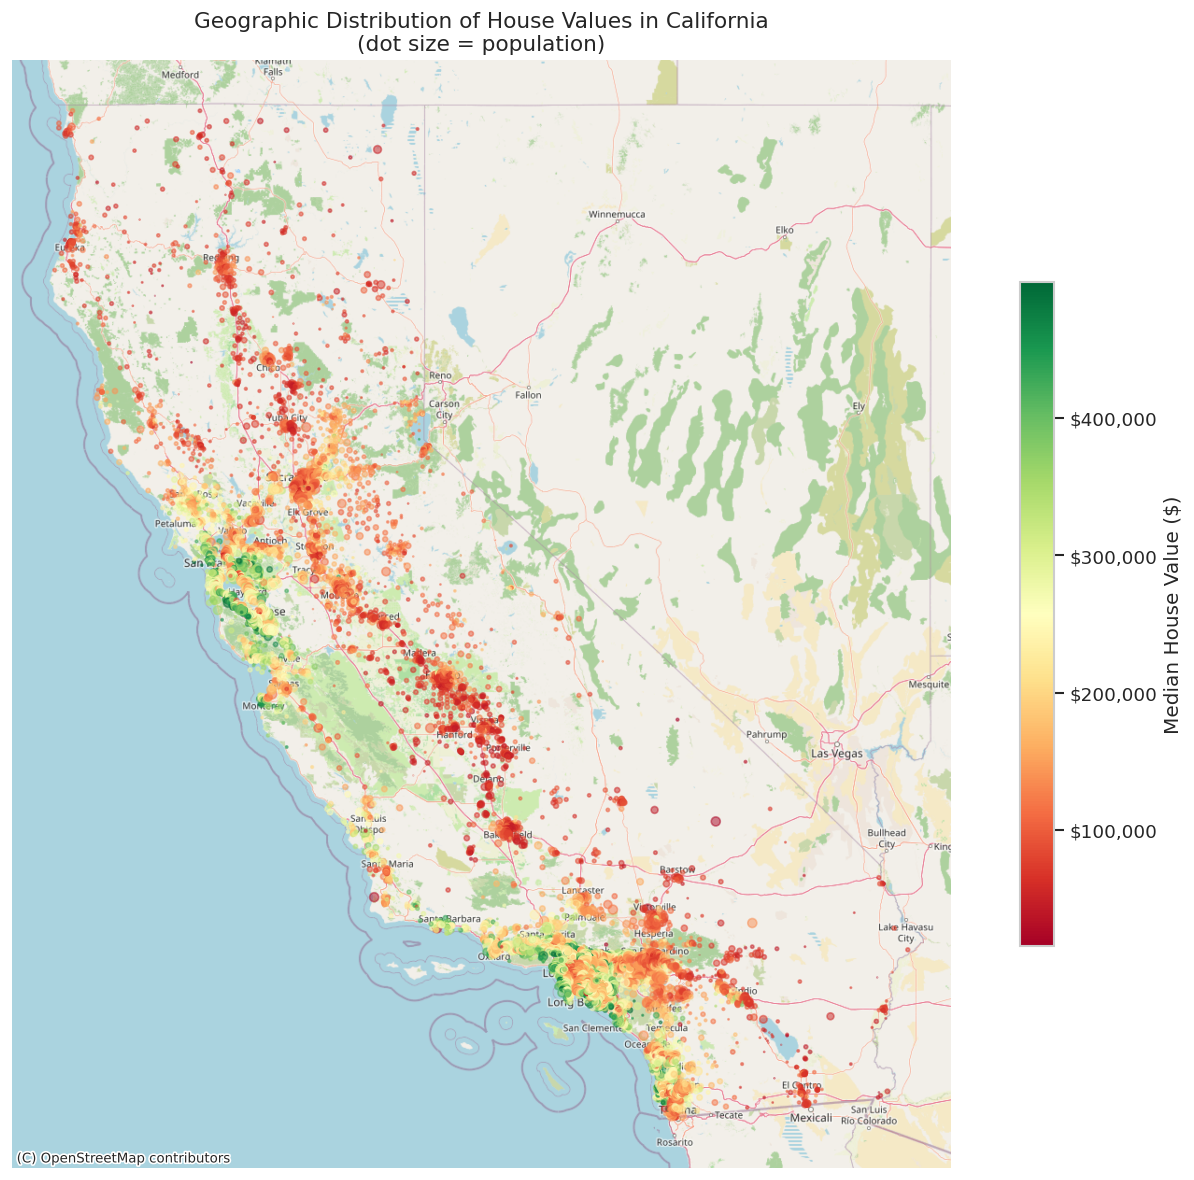

In [13]:
# ============================================================
# CELL 12 - EDA: GEOGRAPHIC MAP WITH REAL BASEMAP
# ============================================================

geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column='median_house_value',
    cmap='RdYlGn',
    alpha=0.5,
    markersize=gdf['population'] / 200,
    legend=True,
    legend_kwds={
        'label': 'Median House Value ($)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'format': mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    }
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=7
)

ax.set_title('Geographic Distribution of House Values in California\n(dot size = population)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('geo_map_real.png', dpi=150, bbox_inches='tight')
plt.show()

##Models


In [14]:
# ============================================================
#PREPROCESSING PIPELINE
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Define feature groups
num_features = [
    'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'median_income',
    'rooms_per_household', 'bedrooms_per_room', 'population_per_household'
]
cat_features = ['ocean_proximity']
target       = 'median_house_value'

X = df[num_features + cat_features]
y = df[target]

# Train / test split (80/20, fixed seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing: scale numerics, one-hot encode categoricals
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  num_features),
    ('cat', categorical_transformer, cat_features)
])

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Features       : {len(num_features)} numerical + {len(cat_features)} categorical")

Training set   : 15,714 rows
Test set       : 3,929 rows
Features       : 9 numerical + 1 categorical


In [16]:
# ============================================================
# METRICS HELPER
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit model, predict on test set, return dict of metrics.
    """
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'Model'     : name,
        'R2 Train'  : round(r2_score(y_tr, y_pred_train), 4),
        'R2 Test'   : round(r2_score(y_te, y_pred_test),  4),
        'RMSE Test' : round(np.sqrt(mean_squared_error(y_te, y_pred_test)), 2),
        'MAE Test'  : round(mean_absolute_error(y_te, y_pred_test), 2),
        'Train Time (s)': round(train_time, 2)
    }
    print(f"[{name}] R2={metrics['R2 Test']} | RMSE=${metrics['RMSE Test']:,.0f} | MAE=${metrics['MAE Test']:,.0f} | {train_time:.1f}s")
    return metrics

results = []

#Linear Regression


In [17]:
# ============================================================
# MODEL 1: LINEAR REGRESSION (OLS) - BASE MODEL
# ============================================================

from sklearn.linear_model import LinearRegression

pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

results.append(evaluate_model('Linear Regression (OLS)', pipe_lr, X_train, y_train, X_test, y_test))

[Linear Regression (OLS)] R2=0.618 | RMSE=$59,772 | MAE=$44,382 | 0.0s


#Lasso

In [18]:
# ============================================================
#  MODEL 2: LASSO & RIDGE
# ============================================================

from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV

# Ridge
pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
param_grid_ridge = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
results.append(evaluate_model('Ridge', gs_ridge, X_train, y_train, X_test, y_test))
print(f"  Best alpha (Ridge): {gs_ridge.best_params_}")

# Lasso
pipe_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])
param_grid_lasso = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
gs_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
results.append(evaluate_model('Lasso', gs_lasso, X_train, y_train, X_test, y_test))
print(f"  Best alpha (Lasso): {gs_lasso.best_params_}")

[Ridge] R2=0.618 | RMSE=$59,772 | MAE=$44,387 | 2.9s
  Best alpha (Ridge): {'model__alpha': 10.0}
[Lasso] R2=0.6179 | RMSE=$59,784 | MAE=$44,415 | 10.1s
  Best alpha (Lasso): {'model__alpha': 100.0}


#Random Forest

In [25]:
# ============================================================
# MODEL 3: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features'     : ['sqrt', 'log2', 0.5]
}

rs_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=5, cv=2, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('Random Forest', rs_rf, X_train, y_train, X_test, y_test))
print(f"  Best params (RF): {rs_rf.best_params_}")

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[Random Forest] R2=0.7063 | RMSE=$52,411 | MAE=$37,760 | 100.0s
  Best params (RF): {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': 20}


#Gradient Boosting

In [27]:
# ============================================================
# MODEL 4: GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_dist_gb = {
    'model__n_estimators'  : [100, 200, 300],
    'model__learning_rate' : [0.05, 0.1, 0.2],
    'model__max_depth'     : [3, 4, 5],
    'model__subsample'     : [0.7, 0.8, 1.0]
}

rs_gb = RandomizedSearchCV(
    pipe_gb, param_dist_gb,
    n_iter=5, cv=2, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('Gradient Boosting', rs_gb, X_train, y_train, X_test, y_test))
print(f"  Best params (GB): {rs_gb.best_params_}")

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[Gradient Boosting] R2=0.7071 | RMSE=$52,345 | MAE=$37,584 | 62.9s
  Best params (GB): {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05}


#SVM

In [29]:
# ============================================================
#  MODEL 5: SUPPORT VECTOR MACHINE (SVR)
# ============================================================

from sklearn.svm import SVR

pipe_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR())
])

param_dist_svr = {
    'model__C'      : [0.1, 1.0, 10.0, 100.0],
    'model__epsilon': [0.1, 0.5, 1.0],
    'model__kernel' : ['rbf', 'linear']
}

rs_svr = RandomizedSearchCV(
    pipe_svr, param_dist_svr,
    n_iter=10, cv=2, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

results.append(evaluate_model('SVR', rs_svr, X_train, y_train, X_test, y_test))
print(f"  Best params (SVR): {rs_svr.best_params_}")

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[SVR] R2=0.5994 | RMSE=$61,209 | MAE=$43,639 | 136.8s
  Best params (SVR): {'model__kernel': 'linear', 'model__epsilon': 0.5, 'model__C': 100.0}


#Neural Network

In [30]:
# ============================================================
# CELL 20 - MODEL 6: NEURAL NETWORK (MLP)
# ============================================================

from sklearn.neural_network import MLPRegressor

pipe_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=500, random_state=42))
])

param_dist_mlp = {
    'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'model__activation'        : ['relu', 'tanh'],
    'model__alpha'             : [0.0001, 0.001, 0.01],
    'model__learning_rate_init': [0.001, 0.01]
}

rs_mlp = RandomizedSearchCV(
    pipe_mlp, param_dist_mlp,
    n_iter=5, cv=2, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)

results.append(evaluate_model('Neural Network (MLP)', rs_mlp, X_train, y_train, X_test, y_test))
print(f"  Best params (MLP): {rs_mlp.best_params_}")

[Neural Network (MLP)] R2=0.6796 | RMSE=$54,747 | MAE=$39,432 | 272.1s
  Best params (MLP): {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.0001, 'model__activation': 'relu'}


#Comparaison

                  Model  R2 Train  R2 Test  RMSE Test   MAE Test  Train Time (s)
      Gradient Boosting    0.7714   0.7071 52345.1800 37584.1200         62.9300
          Random Forest    0.9341   0.7063 52410.7900 37759.8200         99.9600
   Neural Network (MLP)    0.6803   0.6796 54747.3200 39431.6300        272.0600
Linear Regression (OLS)    0.6111   0.6180 59771.8000 44381.5800          0.0500
                  Ridge    0.6111   0.6180 59771.8500 44387.3300          2.9500
                  Lasso    0.6110   0.6179 59783.9000 44415.4300         10.1000
                    SVR    0.5853   0.5994 61209.1700 43638.7100        136.8200
                    SVR    0.3902   0.4079 74418.6100 53784.9600         97.6000


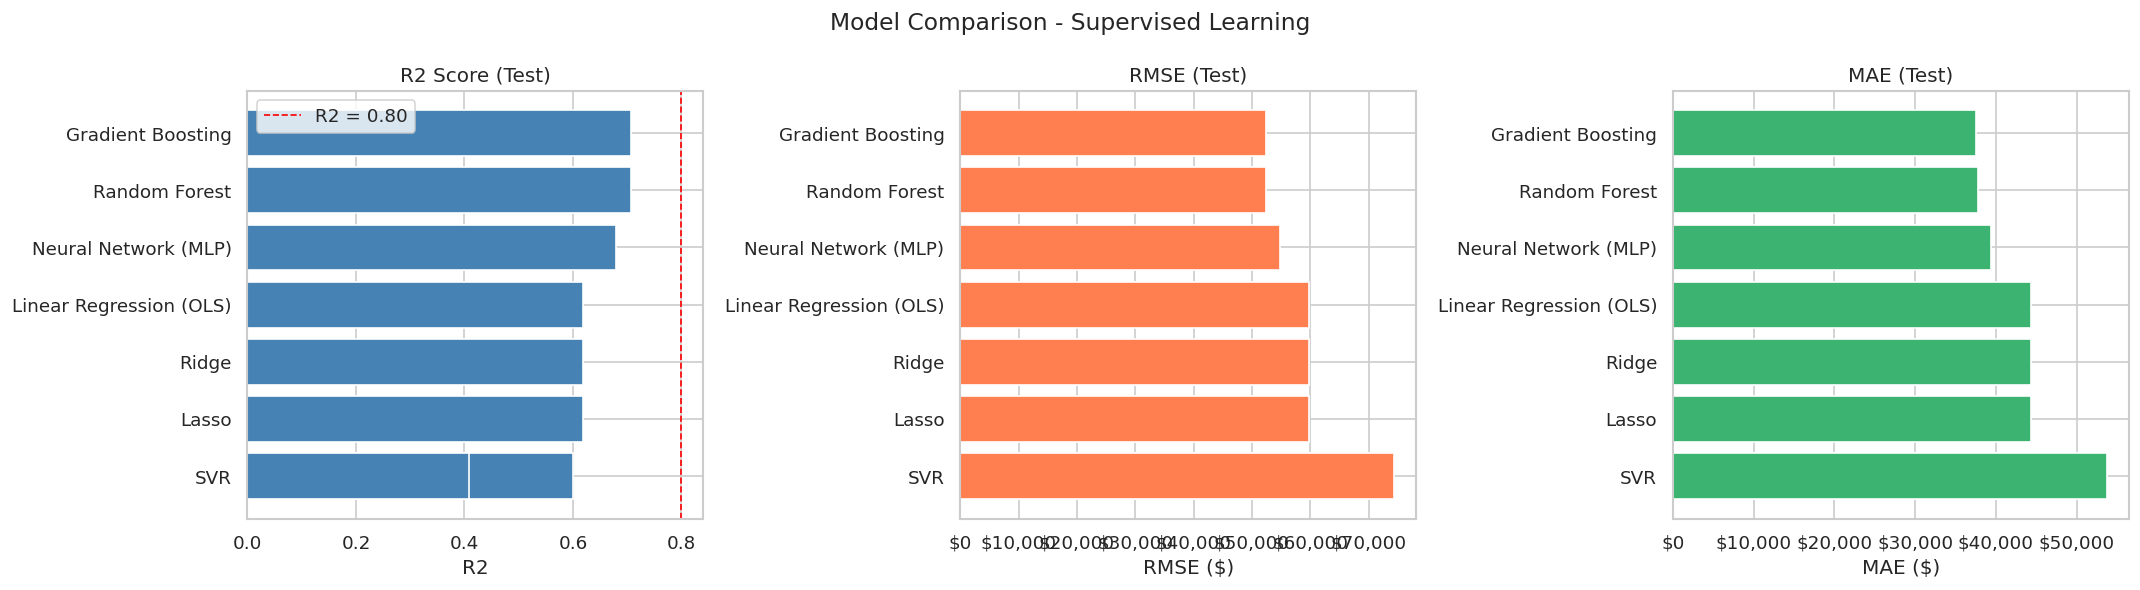

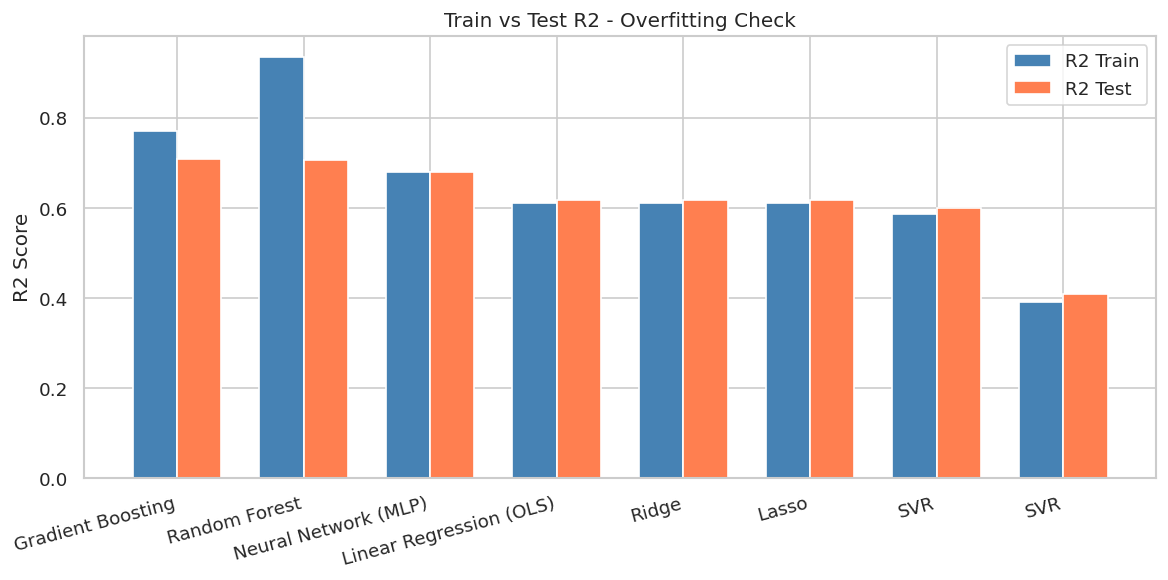

In [31]:
# ============================================================
# CELL 21 - RESULTS COMPARISON
# ============================================================

# --- Summary table ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Test', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# --- Bar chart: R2 Test scores ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['steelblue'] * len(results_df)

# R2 Test
axes[0].barh(results_df['Model'], results_df['R2 Test'], color='steelblue')
axes[0].set_title('R2 Score (Test)')
axes[0].set_xlabel('R2')
axes[0].axvline(x=0.8, color='red', linestyle='--', linewidth=1, label='R2 = 0.80')
axes[0].legend()
axes[0].invert_yaxis()

# RMSE Test
axes[1].barh(results_df['Model'], results_df['RMSE Test'], color='coral')
axes[1].set_title('RMSE (Test)')
axes[1].set_xlabel('RMSE ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

# MAE Test
axes[2].barh(results_df['Model'], results_df['MAE Test'], color='mediumseagreen')
axes[2].set_title('MAE (Test)')
axes[2].set_xlabel('MAE ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].invert_yaxis()

plt.suptitle('Model Comparison - Supervised Learning', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Overfitting check: Train vs Test R2 ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['R2 Train'], width, label='R2 Train', color='steelblue')
ax.bar(x + width/2, results_df['R2 Test'],  width, label='R2 Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('R2 Score')
ax.set_title('Train vs Test R2 - Overfitting Check')
ax.legend()
plt.tight_layout()
plt.savefig('overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()